# TPC1 Single-Channel Analysis Pipeline

This notebook provides a reproducible Python workflow for quantitative analysis of single-channel electrophysiological recordings exported from HEKA PatchMaster ASCII files.

The pipeline includes:
- threshold-based channel state classification
- open probability (Po) calculation
- single-channel amplitude quantification
- batch analysis of recordings
- representative quality-control visualization
- export of analysis results tables

---

## Workflow Overview

1. Import Libraries  
2. User Settings  
3. HEKA ASCII File Import  
4. Single-Channel Analysis Algorithm  
5. Batch Analysis of Recordings  
6. Export Analysis Results  
7. Quality-Control Analysis  
8. Representative Quality-Control Visualization

---

This workflow was developed for reproducible quantitative analysis of single-channel electrophysiological recordings associated with the PNAS manuscript.

In [13]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# ============================================================
# USER SETTINGS
# ============================================================

# Path containing HEKA ASCII files
BASE_PATH = "/content/drive/MyDrive/PatchClampData/Python2/"

# Recordings included in the analysis
FILE_LIST = [
    "recording_01.asc",
    "recording_02.asc",
    "recording_03.asc",
    "recording_04.asc"
]

# Minimum current amplitude required for channel detection
MIN_AMPLITUDE_PA = 1.0

# Output file
OUTPUT_CSV_NAME = "single_channel_results.csv"

## HEKA PatchMaster ASCII File Import

The following function imports single-channel electrophysiological recordings exported from HEKA PatchMaster ASCII files and converts time and current traces into analysis-ready NumPy arrays.

In [2]:
# ============================================================
# LOAD HEKA ASCII FILE
# ============================================================

def load_heka_ascii(file_path):
    """
    Load time and current traces from a HEKA PatchMaster ASCII file.

    Returns
    -------
    t_ms : numpy.ndarray
        Time vector in milliseconds.

    i_pA : numpy.ndarray
        Current trace in picoamperes.
    """

    header_line = None

    with open(file_path, "r") as f:
        for line_number, line in enumerate(f):
            if line.strip().startswith('"Index"'):
                header_line = line_number
                break

    if header_line is None:
        raise ValueError(f"HEKA header not found: {file_path}")

    df = pd.read_csv(file_path, skiprows=header_line)

    df.columns = (
        df.columns
        .str.strip()
        .str.replace('"', "", regex=False)
    )

    time_col = next(c for c in df.columns if "Time[s]" in c and ".1" not in c)
    curr_col = next(c for c in df.columns if "I-mon[A]" in c)

    t_ms = df[time_col].astype(float).to_numpy() * 1e3
    i_pA = df[curr_col].astype(float).to_numpy() * 1e12

    return t_ms, i_pA

## Single-Channel Analysis Algorithm

The following function implements threshold-based quantification of single-channel electrophysiological recordings, including estimation of open probability (Po), unitary current amplitude, and open/closed state classification.

In [3]:
# ============================================================
# ANALYZE SINGLE-CHANNEL TRACE
# ============================================================

def analyze_single_channel(i_pA, min_amplitude_pA=MIN_AMPLITUDE_PA):
    """
    Quantify open probability (Po) and unitary current amplitude
    from a single-channel current trace.

    Analysis workflow
    -----------------
    1. Median baseline correction
    2. Estimation of open and closed current levels
    3. Threshold-based state classification
    4. Calculation of:
        - open probability (Po)
        - unitary current amplitude

    Returns
    -------
    dict
        Analysis results and quality-control metrics.
    """

    # Baseline correction
    i_corr = i_pA - np.median(i_pA)

    # Estimate open and closed current levels
    p_low = np.percentile(i_corr, 15)
    p_high = np.percentile(i_corr, 85)

    open_mask_initial = i_corr < p_low
    closed_mask_initial = i_corr > p_high

    # Quality control
    if np.sum(open_mask_initial) < 10:
        return {
            "status": "failed",
            "reason": "Insufficient open-state points"
        }

    if np.sum(closed_mask_initial) < 10:
        return {
            "status": "failed",
            "reason": "Insufficient closed-state points"
        }

    # Current level estimation
    O = np.mean(i_corr[open_mask_initial])
    C = np.mean(i_corr[closed_mask_initial])

    amplitude = abs(O - C)

    # Flat trace exclusion
    if amplitude < min_amplitude_pA:
        return {
            "status": "flat",
            "reason": "Amplitude below threshold",
            "Amplitude_pA": amplitude,
            "Po": np.nan
        }

    # Threshold-based state classification
    threshold = (O + C) / 2
    open_mask = i_corr < threshold

    # Open probability
    Po = np.mean(open_mask)

    return {
        "status": "ok",
        "Open_level_pA": O,
        "Closed_level_pA": C,
        "Threshold_pA": threshold,
        "Amplitude_pA": amplitude,
        "Po": Po
    }

## Batch Analysis of Single-Channel Recordings

The following section performs threshold-based analysis of all recordings included in the input file list and extracts open probability (Po), unitary current amplitude, threshold values, and recording metadata.

In [ ]:
# ============================================================
# RUN ANALYSIS FOR ALL FILES
# ============================================================

results = []

for fname in FILE_LIST:

    file_path = os.path.join(BASE_PATH, fname)

    # Load recording
    t_ms, i_pA = load_heka_ascii(file_path)

    # Reset time vector
    t_ms = t_ms - t_ms[0]

    # Analyze trace
    out = analyze_single_channel(i_pA)

    # Store results
    results.append({
        "File": fname,
        "Open_level_pA": out.get("Open_level_pA", np.nan),
        "Closed_level_pA": out.get("Closed_level_pA", np.nan),
        "Threshold_pA": out.get("Threshold_pA", np.nan),
        "Amplitude_pA": out.get("Amplitude_pA", np.nan),
        "Open_probability_Po": out.get("Po", np.nan),
        "Duration_s": (t_ms[-1] - t_ms[0]) / 1000,
        "Points_analyzed": len(i_pA)
    })

# Create results table
results_df = pd.DataFrame(results)

# Display results
display(results_df)

## Export Analysis Results

The following section exports the quantified single-channel analysis results as a CSV table containing open probability (Po), unitary current amplitude, threshold values, and recording metadata.

In [ ]:
# ============================================================
# SAVE RESULTS TABLE
# ============================================================

output_path = os.path.join(BASE_PATH, OUTPUT_CSV_NAME)

results_df.to_csv(output_path, index=False)

print(f"Results saved to: {output_path}")

## Representative Quality-Control Visualization

The following section generates representative single-channel traces and current-amplitude histograms used for quality-control assessment of threshold-based channel state classification.

## Quality-Control (QC) Analysis

Representative single-channel recordings were visualized together with the estimated closed-state current level, open-state current level, and classification threshold.

The analysis algorithm estimates open and closed current levels directly from the current-amplitude distribution of each recording. The threshold is positioned between these levels and used as a decision boundary to classify individual data points as either closed or open channel states.

Open probability (Po) is calculated as the fraction of recording time classified as open state, while unitary current amplitude is defined as the difference between the estimated open and closed current levels.

This threshold-based approach minimizes user bias and enables reproducible analysis across recordings.

In [19]:
# ========================================
# MASTER SETUP CELL (RUN FIRST ALWAYS)
# ========================================

# mount drive
from google.colab import drive
drive.mount('/content/drive')

# core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

print("✅ Setup complete")

Mounted at /content/drive
✅ Setup complete


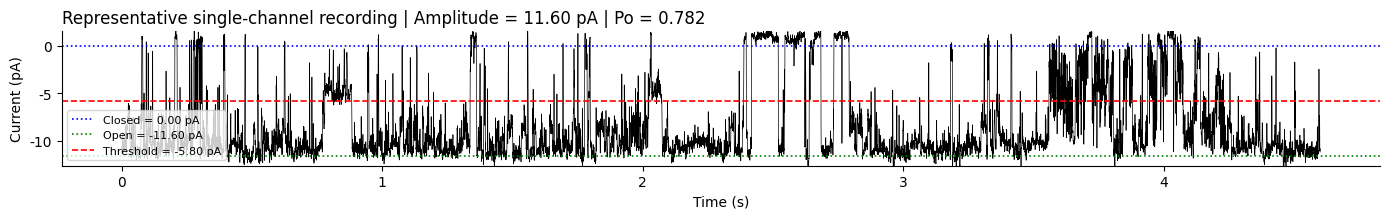

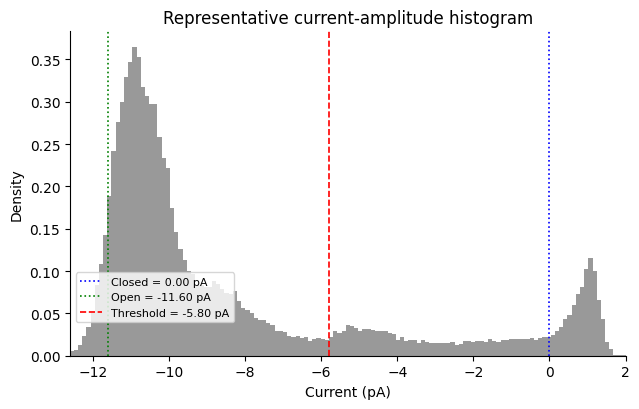

In [26]:
# ============================================================
# GENERATE REPRESENTATIVE QUALITY-CONTROL (QC) FIGURE
# ============================================================

REPRESENTATIVE_QC_FILE = "recording_01.asc"
QC_START_MS = 400

file_path = os.path.join(BASE_PATH, REPRESENTATIVE_QC_FILE)

# Load representative trace
t_ms, i_pA = load_heka_ascii(file_path)
t_ms = t_ms - t_ms[0]

# Remove initial unstable segment for QC visualization
mask = t_ms >= QC_START_MS
t_ms = t_ms[mask]
i_pA = i_pA[mask]

# Analyze representative trace
out = analyze_single_channel(i_pA)

if out["status"] != "ok":
    raise ValueError(f"Analysis failed: {REPRESENTATIVE_QC_FILE}")

# Extract results
time_s = (t_ms - t_ms[0]) / 1000
amplitude = out["Amplitude_pA"]
Po = out["Po"]

closed_level = out["Closed_level_pA"]
open_level = out["Open_level_pA"]
threshold = out["Threshold_pA"]

# Display convention: closed level near 0 pA, openings downward
i_corr = i_pA - np.median(i_pA)
i_display = i_corr - closed_level

closed_display = 0
open_display = open_level - closed_level
threshold_display = threshold - closed_level

# ============================================================
# REPRESENTATIVE TRACE
# ============================================================

plt.figure(figsize=(14, 2.3))

plt.plot(time_s, i_display, color="black", lw=0.5)

plt.axhline(closed_display, color="blue", linestyle=":", lw=1.2,
            label=f"Closed = {closed_display:.2f} pA")

plt.axhline(open_display, color="green", linestyle=":", lw=1.2,
            label=f"Open = {open_display:.2f} pA")

plt.axhline(threshold_display, color="red", linestyle="--", lw=1.2,
            label=f"Threshold = {threshold_display:.2f} pA")

# Balanced y-axis: avoids clipping while preserving publication-style scaling
plt.ylim(open_display - 1.0, 1.5)
plt.yticks([0, -5, -10], ["0", "-5", "-10"])

plt.title(
    f"Representative single-channel recording | "
    f"Amplitude = {amplitude:.2f} pA | Po = {Po:.3f}",
    loc="left"
)

plt.xlabel("Time (s)")
plt.ylabel("Current (pA)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=True, fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

# ============================================================
# CURRENT-AMPLITUDE HISTOGRAM
# ============================================================

plt.figure(figsize=(6.5, 4.2))

plt.hist(i_display, bins=150, density=True, color="gray", alpha=0.8)

plt.axvline(closed_display, color="blue", linestyle=":", lw=1.2,
            label=f"Closed = {closed_display:.2f} pA")

plt.axvline(open_display, color="green", linestyle=":", lw=1.2,
            label=f"Open = {open_display:.2f} pA")

plt.axvline(threshold_display, color="red", linestyle="--", lw=1.2,
            label=f"Threshold = {threshold_display:.2f} pA")

plt.xlim(open_display - 1.0, 2)

plt.title("Representative current-amplitude histogram")
plt.xlabel("Current (pA)")
plt.ylabel("Density")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    frameon=True,
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(0.0, 0.18)
)

plt.tight_layout()
plt.show()

## Quality-Control (QC) Analysis

Representative single-channel recordings were visualized together with the estimated closed-state current level (C), open-state current level (O), and classification threshold.

The analysis algorithm estimates the closed and open current levels directly from the current-amplitude distribution of each recording. The threshold is positioned between these two levels and is used as a decision boundary to classify individual data points as either closed or open channel states.

Open probability (Po) is calculated as the fraction of recording time classified as open state, while unitary current amplitude is defined as the difference between the estimated open and closed current levels.

This threshold-based approach minimizes user bias and enables reproducible automated analysis across recordings.

# TPC1 Single-Channel Analysis Pipeline

This notebook provides a reproducible Python workflow for quantitative analysis of single-channel electrophysiological recordings exported from HEKA PatchMaster ASCII files.

## Features

- Threshold-based closed/open state classification
- Open probability (Po) calculation
- Single-channel amplitude quantification
- Threshold estimation
- Representative QC trace generation
- Current-amplitude histogram generation
- Publication-style visualization

## Input

HEKA PatchMaster ASCII export files (`.asc`).

## Output

- Open probability (Po)
- Single-channel amplitude (pA)
- Threshold values
- Representative QC traces
- Current-amplitude histograms
- Summary results tables

## Requirements

Python 3

Packages:
- numpy
- pandas
- matplotlib

## Usage

Run the notebook:

```bash
TPC1_single_channel_publication_code.ipynb